In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import pandas as pd
import gc
import sys

sys.path.insert(0, '..')
from src import *

In [3]:
data = Data(Filepaths.DATA.value / 'high_freq' / 'T4.0')
dataset = data.read_df(['thermo', 'press', 'press_pot', 'born'], dropdup=['timestep'])
thermo_data, press_data, press_pot_data, born_data = dataset.values()
scale = data.get_scale()

#assert np.all(thermo_data.time == press_data.time)
#assert np.all(thermo_data.time == born_data.time)

dt = thermo_data.time[1] - thermo_data.time[0]

In [4]:
dt

np.float64(0.00019999999999997797)

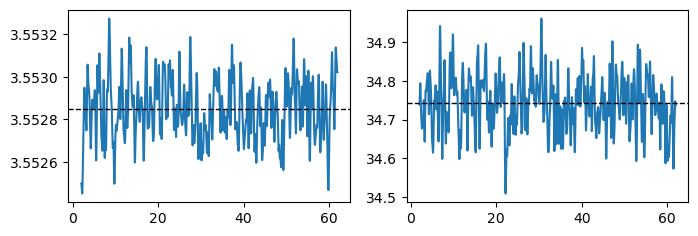

In [5]:
fig, ax = plt.subplots(1,2, figsize=(8,2.5))
ax[0].plot(thermo_data.time, sp.ndimage.gaussian_filter(thermo_data.energy, 500))
ax[0].axhline(thermo_data.energy.mean(), ls='--', c='k', lw=1)

pressure = (press_data.xx + press_data.yy + press_data.zz) / 3
ax[1].plot(thermo_data.time, sp.ndimage.gaussian_filter(pressure, 500))
ax[1].axhline(pressure.mean(), ls='--', c='k', lw=1)
plt.show()

In [6]:
# create 2nd and 4th order tensors out of pressure (stress) and born data
press_raw = np.array(press_data.iloc[:,2:]) * scale
press_pot_raw = np.array(press_pot_data.iloc[:,2:]) * scale
          
stress = -lammps_array_to_matrix(press_raw)
stress_d = stress - stress.mean(axis=0)
press_avg = -np.trace(stress.mean(axis=0)) / 3

stress_kin = -lammps_array_to_matrix(press_raw - press_pot_raw)
stress_kin_mean = stress_kin.mean(axis=0)

born_voigt = lammps_array_to_matrix(born_data.iloc[:,2:]) * scale
born = voigt_to_tensor(born_voigt)

# Born-kinetic term

In [7]:
T = thermo_data.temp.mean()
V = thermo_data.vol.mean()
rho = thermo_data.dens.mean()
print(f'temp:    {T:5.3f}, {thermo_data.temp.std():.1e}')
print(f'volume:  {V:5.0f}, {thermo_data.vol.std():.1e}')
print(f'density: {rho:5.3f}, {thermo_data.vol.std():.1e}')

temp:    4.025, 3.2e-02
volume:   3781, 4.5e-13
density: 1.058, 4.5e-13


In [8]:
CB_avg = born.mean(axis=0) / V
CB_avg_voigt = born_voigt.mean(axis=0) / V
I = np.eye(3)
CK_avg = -4 * sym_dyad(I, stress_kin_mean)
CBK_avg = CB_avg + CK_avg

## Checks

In [8]:
# check kinetic terms with the predictions of equipartition theorem
ds  = np.linalg.norm(stress_kin_mean + rho * T * np.eye(3))
dck = np.linalg.norm(CK_avg - 4*rho*T*sym_dyad(I, I))
print(f"Δσ^kin = {ds:.1e}")
print(f"ΔC^kin = {dck:.1e}")

Δσ^kin = 5.7e-03
ΔC^kin = 2.6e-02


In [9]:
# check the shear quasistatic modulus
ind = 0, 1
skip = len(stress_d) // 10
time = thermo_data.time[skip:] - thermo_data.time[skip]
N = len(time)

stress_ij_crop = stress_d[skip:,*ind]
stress_ij_crop -= stress_ij_crop.mean()
corr = V/T * corr2_fast(stress_ij_crop)
assert np.allclose(corr.imag, np.zeros_like(corr))
corr[N:] = 0
fluct = corr[0].real

print(f"C_BK = {CBK_avg[*ind,*ind]:.1f}, pressure = {press_avg:.1f}, fluct = {fluct:.1f}")
print(f"press + fluct = {press_avg+fluct:.1f} (should be equal C_BK for fluids/gases)")

C_BK = 141.4, pressure = 34.7, fluct = 103.9
press + fluct = 138.6 (should be equal C_BK for fluids/gases)


In [10]:
# check the total Born term against the isotropic one
mu = (CB_avg[0,1,0,1] + CB_avg[0,2,0,2] + CB_avg[1,2,1,2])/3
lam = (CB_avg[0,0,0,0] + CB_avg[1,1,1,1] + CB_avg[2,2,2,2])/3 - 2*mu
print(f'lam = {lam:.3f}')
print(f'mu  = {mu:.3f}')

CB_ref = lam*np.einsum('ij,kl->ijkl', I, I) + 2*mu*sym_dyad(I, I)
print(np.linalg.norm(CB_ref - CB_avg))

lam = 132.907
mu  = 133.018
0.9845768223134296


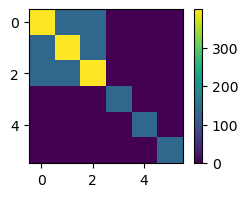

In [11]:
plt.figure(figsize=(3,2))
plt.imshow(CB_avg_voigt)
plt.colorbar()

# Dynamic shear modulus

In [9]:
ind = 0, 1
skip = len(stress_d) // 10
time = thermo_data.time[skip:] - thermo_data.time[skip]
N = len(time)

stress_shear_crop = stress_d[skip:,*ind]
stress_shear_crop -= stress_shear_crop.mean()
corr = V/T * corr2_fast(stress_shear_crop)
corr[N:] = 0
fluct = corr[0].real

modulus_t = CBK_avg[*ind,*ind] + corr.real[:N] - fluct - press_avg

In [10]:
zero_cut_ind = N//5
print(f"mean: {corr.real[zero_cut_ind:N].mean():.2e}, \
std: {corr.real[zero_cut_ind:N].std():.2e}")

mean: -1.04e-01, std: 1.86e+00


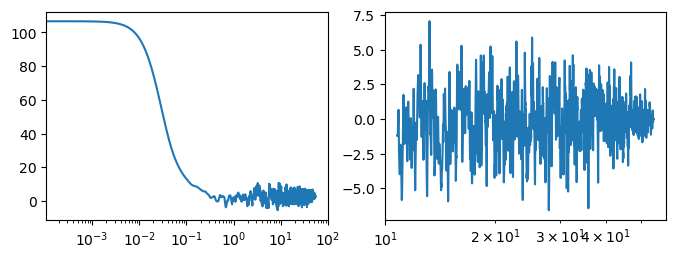

In [11]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,2.7))
axes[0].plot(time, modulus_t)
axes[0].set_xscale('log')
axes[1].plot(time[zero_cut_ind:], corr.real[zero_cut_ind:N])

#axes[0].plot(time, modulus_t_wiener)
#axes[1].plot(time[zero_cut_ind:], wiener(corr.real[:N], 100)[zero_cut_ind:])
axes[1].set_xscale('log')

In [12]:
gc.collect()

30014

In [12]:
freq = np.fft.fftfreq(2*N, d=dt)[:N] * 2 * np.pi
corr_freq = 1j*freq* dt*np.fft.fft(corr)[:N]
modulus_freq = CBK_avg[*ind,*ind] + corr_freq - fluct - press_avg

freq_bins = np.geomspace(freq[1], freq[-1], num=100)
log_freq = (freq_bins[1:] + freq_bins[:-1])/2
modulus_log = np.diff(trapz_cumsum(freq_bins, freq, modulus_freq)) / np.diff(freq_bins)

log_freq_, modulus_log_ = avg_log(freq, modulus_freq, num_bins=40)

In [13]:
freq_ind_cut = np.argmax((modulus_log.real >= modulus_t[0])[-1::-1])
freq_ind_cut

np.int64(23)

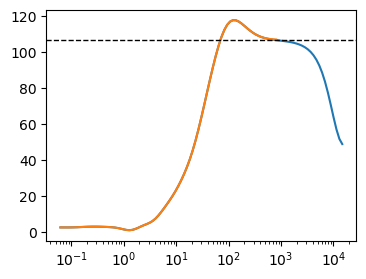

In [14]:
plt.figure(figsize=(4,3))
plt.plot(log_freq, 
         sp.ndimage.gaussian_filter1d(modulus_log.real, 3))
plt.plot(log_freq[:-freq_ind_cut], 
         sp.ndimage.gaussian_filter1d(modulus_log.real[:-freq_ind_cut], 3))
plt.axhline(modulus_t[0], c='k', ls='--', lw=1)
plt.xscale("log")

In [15]:
modulus_log.real.max()

np.float64(122.58074456675219)

## Dynamic P-wave modulus

In [31]:
ind = 0, 0
skip = len(stress_d) // 10
time = thermo_data.time[skip:] - thermo_data.time[skip]
N = len(time)

#stress_tr_crop = (stress_d[skip:,0,0] + stress_d[skip:,1,1] + stress_d[skip:,2,2]) / 3
stress_tr_crop = stress_d[skip:,0,0]
stress_tr_crop -= stress_tr_crop.mean()
corr = V/T * corr2_fast(stress_tr_crop)
corr[N:] = 0
fluct = corr[0].real

In [36]:
#CBK_tr_avg = (CBK_avg[0,0,0,0] + CBK_avg[1,1,1,1] + CBK_avg[2,2,2,2]) / 3
CBK_tr_avg = CBK_avg[0,0,0,0]
bulk_t = CBK_tr_avg + corr.real[:N] - fluct - press_avg

In [14]:
zero_cut_ind = N//5
print(f"mean: {corr.real[zero_cut_ind:N].mean():.2e}, \
std: {corr.real[zero_cut_ind:N].std():.2e}")

mean: -1.24e-02, std: 3.09e+00


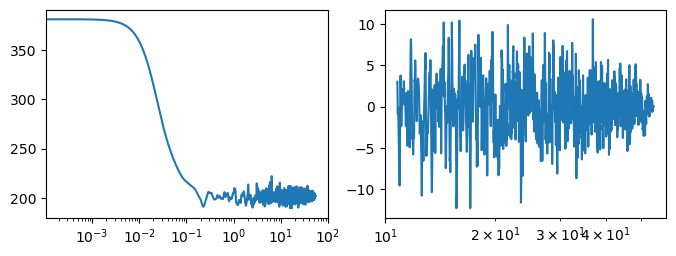

In [15]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8,2.7))
axes[0].plot(time, bulk_t)
axes[0].set_xscale('log')
axes[1].plot(time[zero_cut_ind:], corr.real[zero_cut_ind:N])
axes[1].set_xscale('log')

In [16]:
gc.collect()

45136

In [20]:
freq = np.fft.fftfreq(2*N, d=dt)[:N] * 2 * np.pi
corr_freq = 1j*freq* dt*np.fft.fft(corr)[:N]
bulk_freq = CBK_tr_avg + corr_freq - fluct - press_avg

freq_bins = np.geomspace(freq[1], freq[-1], num=100)
log_freq = (freq_bins[1:] + freq_bins[:-1])/2
bulk_log = np.diff(trapz_cumsum(freq_bins, freq, bulk_freq)) / np.diff(freq_bins)

log_freq_, bulk_log_ = avg_log(freq, bulk_freq, num_bins=40)

In [21]:
freq_ind_cut = np.argmax((bulk_log.real >= bulk_t[0])[-1::-1])
freq_ind_cut

np.int64(21)

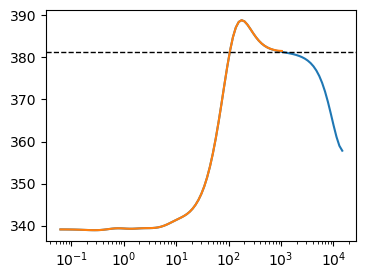

In [22]:
plt.figure(figsize=(4,3))
plt.plot(log_freq, 
         sp.ndimage.gaussian_filter1d(bulk_log.real, 3))
plt.plot(log_freq[:-freq_ind_cut], 
         sp.ndimage.gaussian_filter1d(bulk_log.real[:-freq_ind_cut], 3))
plt.axhline(bulk_t[0], c='k', ls='--', lw=1)
plt.xscale("log")

## Averaged dynamic P-wave

In [35]:
corr = 0
step_size = 5000
steps = len(stress_d) // step_size
for i, _ in enumerate(ProgressBarText(range(steps), 25)):
    s = stress_d[i*step_size:(i+1)*step_size, 0, 0].copy()
    corr += V/T * corr2_fast(s).real / steps

N = len(corr) // 2
time = thermo_data.time[:N] - thermo_data.time[0]
corr[N:] = 0
fluct = corr[0].real

Progress: |█████████████████████████| 100.0% Elapsed: 0:00:00, Estimated: 0:00:00


In [39]:
#CBK_tr_avg = (CBK_avg[0,0,0,0] + CBK_avg[1,1,1,1] + CBK_avg[2,2,2,2]) / 3
CBK_tr_avg = CBK_avg[0,0,0,0]
bulk_t = CBK_tr_avg + corr.real[:N] - fluct# - press_avg

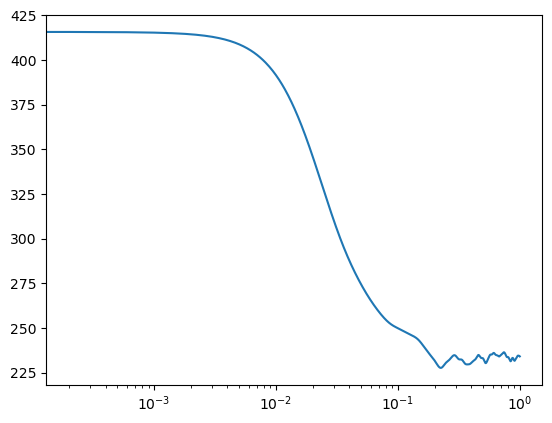

In [40]:
plt.plot(time, bulk_t)
plt.xscale('log')

In [41]:
np.savetxt(Filepaths.DATA.value / 'moduli_t' / 'pwave_dt0.0002', bulk_t)